# Tarea 1: Demographic Profile & Migration Landscape

**Group:** 7

**Names:** Macarena Fraga, Sebastian Bolomey

**Date**: 23/03/2026

# Parte 0: Importando Paquetes, Carga y Unión de Datos

In [3]:
import pandas as pd

# Rutas Drive
path_v = "/Users/sebastianbolomey/Documents/IELE756/data/viviendas_censo2024.parquet"
path_h = "/Users/sebastianbolomey/Documents/IELE756/data/hogares_censo2024.parquet"
path_p = "/Users/sebastianbolomey/Documents/IELE756/data/personas_censo2024.parquet"

# VIVIENDAS
vivienda = pd.read_parquet(path_v, columns=["id_vivienda", "comuna"])
# Filtrar Pudahuel (13124) y Lo Prado (13117)
vivienda = vivienda[vivienda['comuna'].isin([13124, 13117])]

# HOGARES
# Incluir 'id_vivienda' e 'id_hogar' aquí
hogar = pd.read_parquet(path_h, columns=["id_vivienda", "id_hogar"])
vh = hogar.merge(vivienda, on='id_vivienda', how='inner')

# PERSONAS
# Incluir llaves 'id_vivienda' e 'id_hogar' para el join
cols_p = ["id_vivienda", "id_hogar", "id_persona", "sexo", "edad",
          "p25_lug_nacimiento", "escolaridad", "sit_fuerza_trabajo", "p27_nacionalidad", "p27_nacionalidad_rec",
          "p24_lug_resid5", "p26_llegada_periodo" , "p27_nacionalidad_esp", "parentesco"]

persona = pd.read_parquet(path_p, columns=cols_p)

# UNIÓN FINAL (Triple Join)
# Unimos por ambas llaves para asegurar la jerarquía correcta
censo_full = persona.merge(vh, on=['id_vivienda', 'id_hogar'], how='inner')

print(f"Columnas disponibles: {censo_full.columns.tolist()}")
print(f"Población total filtrada: {len(censo_full)}")

Columnas disponibles: ['id_vivienda', 'id_hogar', 'id_persona', 'sexo', 'edad', 'p25_lug_nacimiento', 'escolaridad', 'sit_fuerza_trabajo', 'p27_nacionalidad', 'p27_nacionalidad_rec', 'p24_lug_resid5', 'p26_llegada_periodo', 'p27_nacionalidad_esp', 'parentesco', 'comuna']
Población total filtrada: 319110


# Parte 1: Perfil Demográfico

In [4]:
# Edad Mediana por Comuna

edad_mediana = censo_full.groupby('comuna')['edad'].median()
print("Edad Mediana (13124=Pudahuel, 13117=Lo Prado):")
print(edad_mediana)

Edad Mediana (13124=Pudahuel, 13117=Lo Prado):
comuna
13117    39.0
13124    36.0
Name: edad, dtype: float64


### 1.1 Piramide de edad por sexo.


/var/folders/p_/wy68s7v50tgdqfjf03r42hn00000gn/T/ipykernel_15924/4265277360.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  pyramid = censo_full.groupby(["age_group","sexo"]).size().unstack()


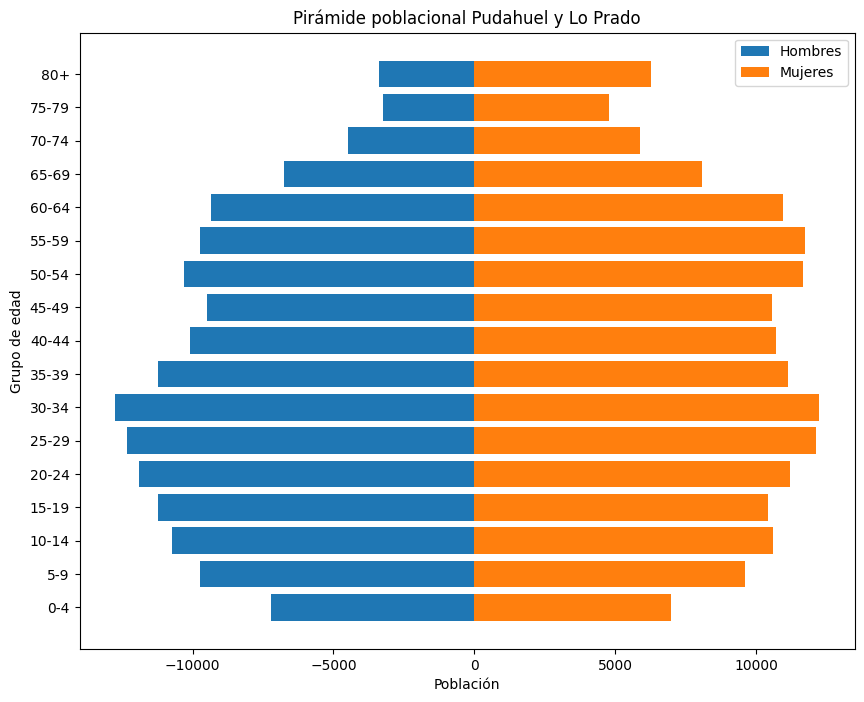

In [6]:
import matplotlib.pyplot as plt

# Crear grupos de edad (5 años)
bins = list(range(0,81,5)) + [200]

labels = [f"{i}-{i+4}" for i in range(0,80,5)] + ["80+"]

censo_full["age_group"] = pd.cut(
    censo_full["edad"],
    bins=bins,
    labels=labels,
    right=False
)

# Contar personas por sexo y edad
pyramid = censo_full.groupby(["age_group","sexo"]).size().unstack()

# hombres negativos para lado izquierdo

pyramid[1] = -pyramid[1]

# Graficar pirámide poblacional
plt.figure(figsize=(10,8))

plt.barh(pyramid.index, pyramid[1], label="Hombres")
plt.barh(pyramid.index, pyramid[2], label="Mujeres")

plt.title("Pirámide poblacional Pudahuel y Lo Prado")
plt.xlabel("Población")
plt.ylabel("Grupo de edad")

plt.legend()

plt.show()

La pirámide muestra un mayor ensanchamiento en la población de grupos de edad adulta-joven (aproximadamente entre los 20 y 60 años). Esto indica una alta proporción de población en edad de trabajar, lo cual es favorable para la fuerza laboral de las comunas y el país en general. Los grupos más numerosos se encuentran entre los 25-34 años para amos sexos.

Se observa una mayor longevidad femenina pero igualmente baja población en edad avanzada (en general). La base moderada podría indicar una tendencia hacia un crecimiento lento de la población o incluso una ligera contracción en un futuro próximo.

### 1.2 Dependency Ratio


In [7]:

young = censo_full[censo_full["edad"] <= 14]

old = censo_full[censo_full["edad"] >= 65]

working = censo_full[
    (censo_full["edad"] >= 15) &
    (censo_full["edad"] <= 64)
]

dependency_ratio = (len(young) + len(old)) / len(working)

print("Dependency Ratio:", dependency_ratio)

Dependency Ratio: 0.4417316502362902


### 1.3 Household size distribution by nationality of head of household

/var/folders/p_/wy68s7v50tgdqfjf03r42hn00000gn/T/ipykernel_15924/2993755265.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df_plot.groupby(['nacionalidad_jefe', 'tamano_cat']).size().reset_index(name='count')


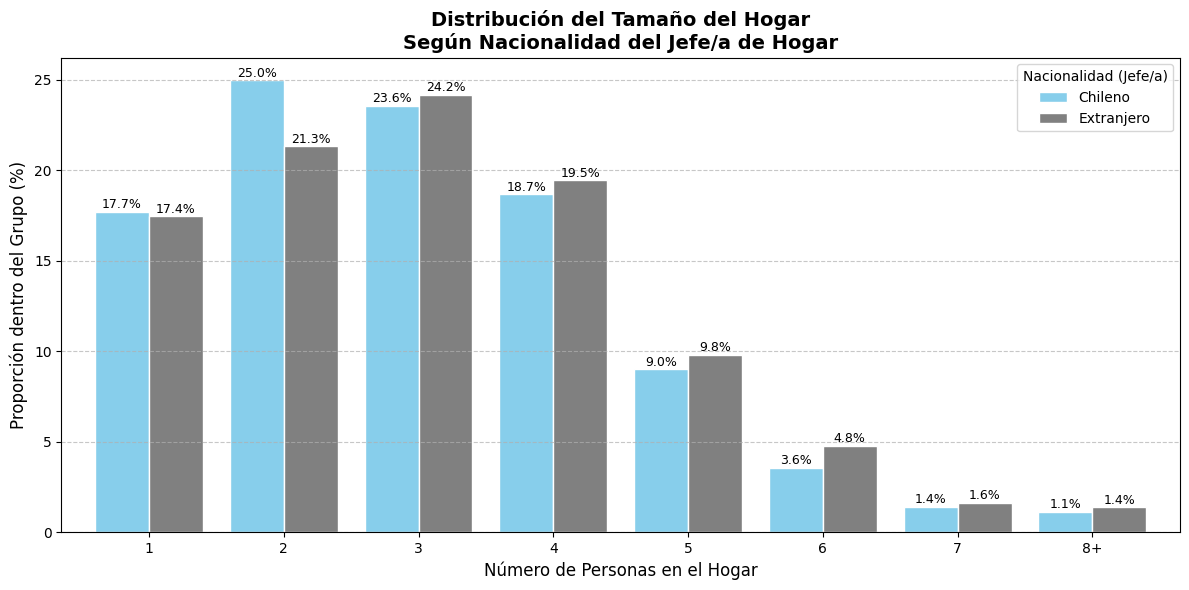

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Calcular el tamaño del hogar
# Agrupar por vivienda y hogar para obtener el número exacto de personas por hogar
hogares_size = censo_full.groupby(['id_vivienda', 'id_hogar']).size().reset_index(name='n_personas')

# Limitar el tamaño a 8+
hogares_size['tamano_cat'] = np.where(hogares_size['n_personas'] >= 8, '8+', hogares_size['n_personas'].astype(str))

# Asegurar que las categorías estén ordenadas correctamente para el gráfico
orden = ['1', '2', '3', '4', '5', '6', '7', '8+']
hogares_size['tamano_cat'] = pd.Categorical(hogares_size['tamano_cat'], categories=orden, ordered=True)

jefes = censo_full[censo_full['parentesco'] == 1].copy()

# Aplicar el mismo mapeo de Nacionalidad que usamos para la pirámide
condiciones = [
    jefes['p27_nacionalidad'].isin([1, 2]), # Asumiendo que 1 y 2 son relevantes para la nacionalidad
    jefes['p27_nacionalidad'] == 3 # Asumiendo que 3 es 'Extranjero'
]
opciones = ['Chileno', 'Extranjero']
jefes['nacionalidad_jefe'] = np.select(condiciones, opciones, default='Drop')

# Mantener solo las filas válidas
jefes_validos = jefes[jefes['nacionalidad_jefe'] != 'Drop'][['id_vivienda', 'id_hogar', 'nacionalidad_jefe']]

# 3. Unir datos de tamaño con datos de nacionalidad
df_plot = pd.merge(hogares_size, jefes_validos, on=['id_vivienda', 'id_hogar'], how='inner')

# Calcular las proporciones (%) dentro de cada grupo de nacionalidad
counts = df_plot.groupby(['nacionalidad_jefe', 'tamano_cat']).size().reset_index(name='count')
totals = counts.groupby('nacionalidad_jefe')['count'].transform('sum')
counts['proportion'] = (counts['count'] / totals) * 100

# Pivotar los datos para poder graficar fácilmente barras agrupadas lado a lado
pivot_df = counts.pivot(index='tamano_cat', columns='nacionalidad_jefe', values='proportion')

# 4. Graficar la distribución
ax = pivot_df.plot(kind='bar', figsize=(12, 6), width=0.8, color=['skyblue', 'gray'], edgecolor='white') # Colores cambiados

# Formato
plt.title('Distribución del Tamaño del Hogar\nSegún Nacionalidad del Jefe/a de Hogar', fontsize=14, fontweight='bold')
plt.xlabel('Número de Personas en el Hogar', fontsize=12)
plt.ylabel('Proporción dentro del Grupo (%)', fontsize=12)
plt.xticks(rotation=0)
plt.legend(title='Nacionalidad (Jefe/a)')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor en la parte superior de las barras para mayor claridad
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

Se observa que la gran mayoria de los hogares en Pudahuel y Lo Prado son de pocas personas. A medida que aumenta el número de personas por hogar, la cantidad de estos hogares disminuye muy rápidamente.
Predominan los hogares de 2 a 3 personas y existen muy pocos con 5 o más de ellas.

### 1.4 Education and employment

In [9]:
# 1.4 Education and employment

# Filtrar personas de 25 años o más
edu_25 = censo_full[censo_full["edad"] >= 25]

# Elimiar valores missing (-99)
edu_25 = edu_25[edu_25["escolaridad"] != -99]

# Calcular promedio de escoaridad por comuna y nacionalidad
schooling = edu_25.groupby(
    ["comuna","p27_nacionalidad_rec"]
)["escolaridad"].mean().reset_index()

print(schooling)

   comuna  p27_nacionalidad_rec  escolaridad
0   13117                   -99     9.750000
1   13117                     1    11.056758
2   13117                     2    12.004300
3   13124                   -99    11.992248
4   13124                     1    11.692555
5   13124                     2    12.441822


In [10]:
# Filtrar personas en edad laboral
work_age = censo_full[
    (censo_full["edad"] >= 15) &
    (censo_full["edad"] <= 64)
].copy()

#sit_fuerza_trabajo = 1  → ocupado

# Crear variable empleado
work_age["empleado"] = work_age["sit_fuerza_trabajo"] == 1

# Calcular tasa de empleo
employment = work_age.groupby(
    ["comuna","p27_nacionalidad_rec"]
)["empleado"].mean().reset_index()

print(employment)

# Unir educación y empleo
results = schooling.merge(
    employment,
    on=["comuna","p27_nacionalidad_rec"]
)

results.columns = [
    "comuna",
    "nacionalidad",
    "escolaridad media",
    "tasa de empleo"
]

print(results)

   comuna  p27_nacionalidad_rec  empleado
0   13117                   -99  0.008547
1   13117                     1  0.625905
2   13117                     2  0.754180
3   13124                   -99  0.073657
4   13124                     1  0.619386
5   13124                     2  0.738583
   comuna  nacionalidad  escolaridad media  tasa de empleo
0   13117           -99           9.750000        0.008547
1   13117             1          11.056758        0.625905
2   13117             2          12.004300        0.754180
3   13124           -99          11.992248        0.073657
4   13124             1          11.692555        0.619386
5   13124             2          12.441822        0.738583


Los chilenos tienen una tasa de empleo menor que los extranjeros

In [11]:
results = results[results["nacionalidad"] != -99]

##### Ahora graficando:

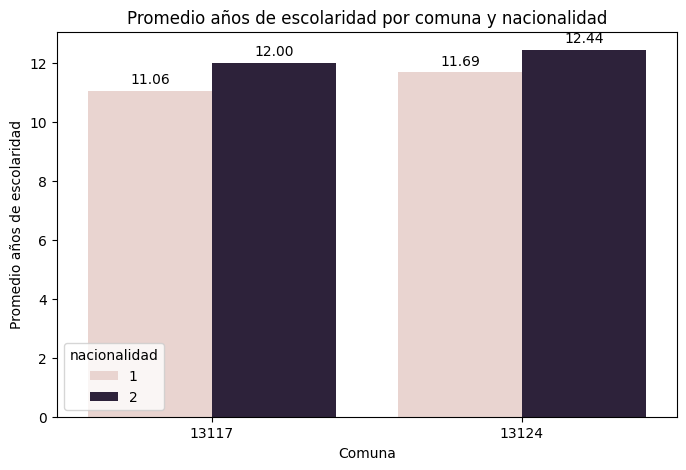

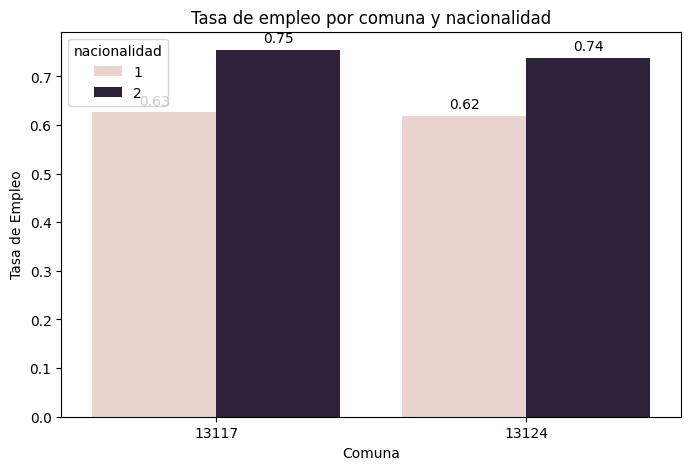

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
# =======================
# Grafico educación promedio
# =======================
plt.figure(figsize=(8,5))

# 1. Asignando el plot a la variable (ax1)
ax1 = sns.barplot(
    data=results,
    x="comuna",
    y="escolaridad media",
    hue="nacionalidad"
)

# 2. Recorrer las barras y agregar etiquetas.
for container in ax1.containers:
    ax1.bar_label(container, fmt='%.2f', padding=3)

plt.title("Promedio años de escolaridad por comuna y nacionalidad")
plt.ylabel("Promedio años de escolaridad")
plt.xlabel("Comuna")

plt.show()
# =======================
# Gráfico tasa de empleo
# =======================
plt.figure(figsize=(8,5))

ax2 = sns.barplot(
    data=results,
    x="comuna",
    y="tasa de empleo",
    hue="nacionalidad"
)
# Recorrer las barras y agregar etiquetas.
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.2f', padding=3)

plt.title("Tasa de empleo por comuna y nacionalidad")
plt.ylabel("Tasa de Empleo")
plt.xlabel("Comuna")

plt.show()

Los resultados muestran diferencias notables entre residentes nacidos en Chile y residentes nacidos en el extranjero en ambas comunas.

Los residentes nacidos en el extranjero presentan un promedio de años de escolaridad mayor que los nacidos en Chile. En la comuna 13117, los extranjeros tienen un promedio de aproximadamente 12 años de escolaridad, en comparación con los aproximadamente 11 años de los chilenos. Un patrón similar se observa en la comuna 13124, donde los extranjeros también muestran un mayor nivel educativo.

Esto podría indicar que los inmigrantes en estas comunas pueden tener una fuerte participación en el mercado laboral.


# Part 2 : Migration Landscape

### 2.1 % foreing-born by comuna

In [14]:
# Eliminar valores missing
mig = censo_full[censo_full["p27_nacionalidad_rec"] != -99]

# Crear variable: Es extranjero
mig["extranjeros"] = mig["p27_nacionalidad_rec"] == 2



# Calcular % extranjeros por comuna
foreign_share = mig.groupby("comuna")["extranjeros"].mean().reset_index()

# convertir a porcentaje
foreign_share["%"] = foreign_share["extranjeros"] * 100

# Crear un diccionario con el código y el nombre correspondiente
nombres_comunas = {
    13117: "Lo Prado",
    13124: "Pudahuel"
}

# Reemplazar los valores en la columna "comuna"
foreign_share["comuna"] = foreign_share["comuna"].replace(nombres_comunas)

print(foreign_share)

     comuna  extranjeros          %
0  Lo Prado     0.133388  13.338767
1  Pudahuel     0.067841   6.784127


/var/folders/p_/wy68s7v50tgdqfjf03r42hn00000gn/T/ipykernel_15924/1506022494.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mig["extranjeros"] = mig["p27_nacionalidad_rec"] == 2


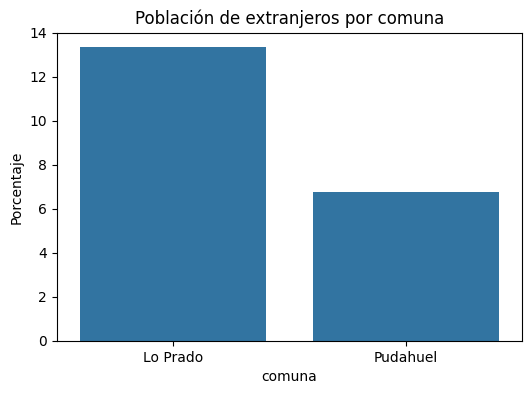

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

# We use the exact lowercase 'comuna' here
sns.barplot(
    data=foreign_share,
    x="comuna", 
    y="%" 
)

plt.ylabel("Porcentaje")
plt.title("Población de extranjeros por comuna")
plt.show() # Renders the plot cleanly

### 2.2 Top nationalities

p27_nacionalidad_esp
862    10014
604     7517
170     4640
332     1597
5       1595
68       764
13       618
32       379
142      169
150       81
Name: count, dtype: int64


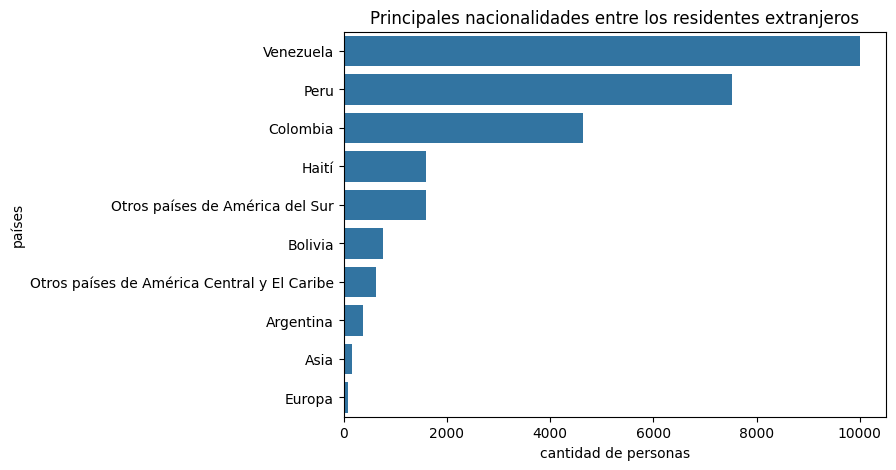

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# 2.2 Top nationalities

# Ahora usamos la variable p27_nacionalidad (nacionalidad específica)

# Filtrar solo extranjeros usando p27_nacionalidad_rec, que indica si es extranjero o no
foreigners = censo_full[censo_full["p27_nacionalidad_rec"] == 2]

# Contar nacionalidades específicas de esos extranjeros (p27_nacionalidad_esp)
top_nat = foreigners["p27_nacionalidad_esp"].value_counts().head(10)

print(top_nat)

# Convertir a dataframe
top_nat = top_nat.reset_index()

top_nat.columns = ["nationality_code", "cantidad de personas"]

# Traducir los códigos a países
country_map = {
    152: "Chile",
    604: "Peru",
    862: "Venezuela",
    170: "Colombia",
    68: "Bolivia",
    32: "Argentina",
    332: "Haití",
    5: "Otros países de América del Sur",
    13: "Otros países de América Central y El Caribe",
    142: "Asia",
    150: "Europa"
}

top_nat["países"] = top_nat["nationality_code"].map(country_map)

# Gráfico
plt.figure(figsize=(7,5))

sns.barplot(
    data=top_nat,
    y="países",
    x="cantidad de personas"
)

plt.title("Principales nacionalidades entre los residentes extranjeros")

plt.show()

### 2.3

   comuna  p24_lug_resid5   count
0   13117               2   70065
1   13117               3   12268
2   13117               4    4439
3   13124               2  183413
4   13124               3   26391
5   13124               4    5707


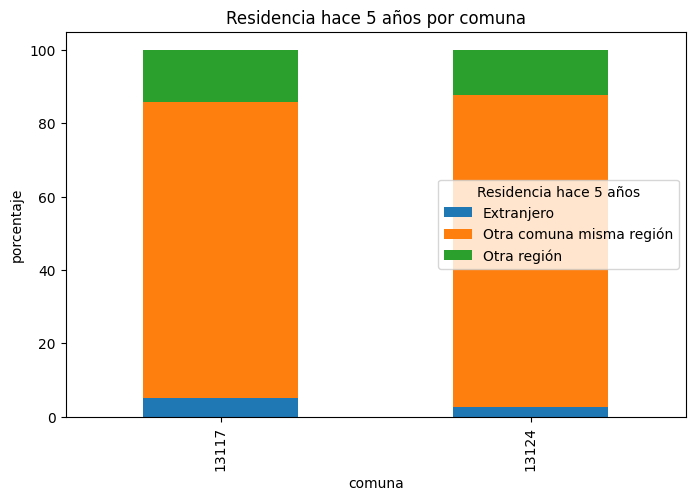

In [19]:
# 2.3 Residence 5 years ago

# Utilizamos la variable p24_lug_resid5 que registra dónde vivia la persona hace 5 años del censo

# Filtrar personas mayores de 5 años
res5 = censo_full[censo_full["edad"] >= 5]

# eliminar missing
res5 = res5[res5["p24_lug_resid5"] != -99]

# Contar tipos de migración
res5_counts = res5.groupby(
    ["comuna","p24_lug_resid5"]
).size().reset_index(name="count")

print(res5_counts)


# Crear categoría de migración
migration_map = {
    1: "Misma comuna",
    2: "Otra comuna misma región",
    3: "Otra región",
    4: "Extranjero"
}
res5["migration_category"] = res5["p24_lug_resid5"].map(migration_map)

# Contar personas por comuna
migration_counts = res5.groupby(
    ["comuna", "migration_category"]
).size().reset_index(name="count")

# Calcular porcentajes
migration_counts["percent"] = migration_counts.groupby("comuna")["count"].transform(
    lambda x: x / x.sum() * 100
)

# Crear tabla para stacked bar chart
migration_pivot = migration_counts.pivot(
    index="comuna",
    columns="migration_category",
    values="percent"
)

# Gráfico de barras apilada
migration_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.ylabel("porcentaje")
plt.title("Residencia hace 5 años por comuna")
plt.legend(title="Residencia hace 5 años")

plt.show()

Los resultados muestran que la mayoría de los residentes vivían en una comuna diferente dentro de la misma región cinco años antes del censo. Una proporción menor se trasladó desde otras regiones de Chile, mientras que una pequeña parte residía en el extranjero. Los patrones son relativamente similares en ambas comunas, aunque la comuna 13124 presenta una migración internacional ligeramente menor.

### 2.4

p26_llegada_periodo
1.0    3256
2.0    6446
3.0    8030
4.0    3586
5.0    2107
6.0    2446
7.0     671
8.0      76
Name: count, dtype: int64


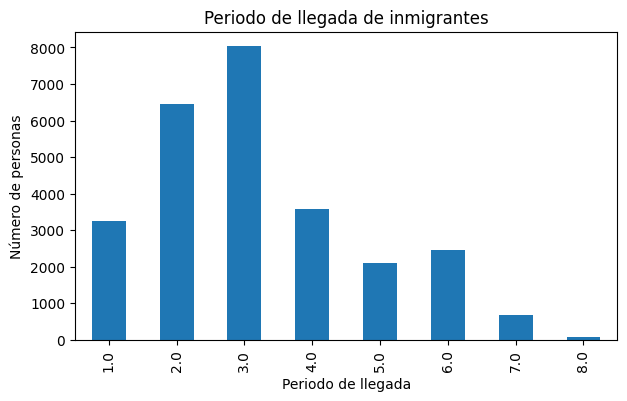

In [20]:
# 2.4 Arrival period of inmigrants

# Solo extranjeros
arrival = censo_full[censo_full["p27_nacionalidad_rec"] == 2]

arrival = arrival[arrival["p26_llegada_periodo"] != -99]


# Contar periodos
arrival_counts = arrival["p26_llegada_periodo"].value_counts().sort_index()

print(arrival_counts)

arrival_counts.plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Periodo de llegada de inmigrantes")

plt.ylabel("Número de personas")
plt.xlabel("Periodo de llegada")

plt.show()

La distribución de los períodos de llegada muestra que la mayoría de los inmigrantes llegaron en períodos relativamente recientes. El mayor número de llegadas se concentra en el período 3 (entre 2017 y 2019), seguido del período 2 (entre 2020 y 2022), lo que indica un aumento significativo de la inmigración durante esos años. Los periodos anteriores presentan un menor número de migrantes, y las categorías de llegada más antiguas representan solo una pequeña fracción de la población nacida en el extranjero. En general, esto sugiere que la inmigración en estas comunas es en gran medida un fenómeno reciente, que refleja las tendencias migratorias más amplias observadas en Chile en las últimas décadas.

# Part 3

In [ ]:
# Part 3 : Spacial Visualization

# instalar librerías geográficas
!pip install geopandas

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

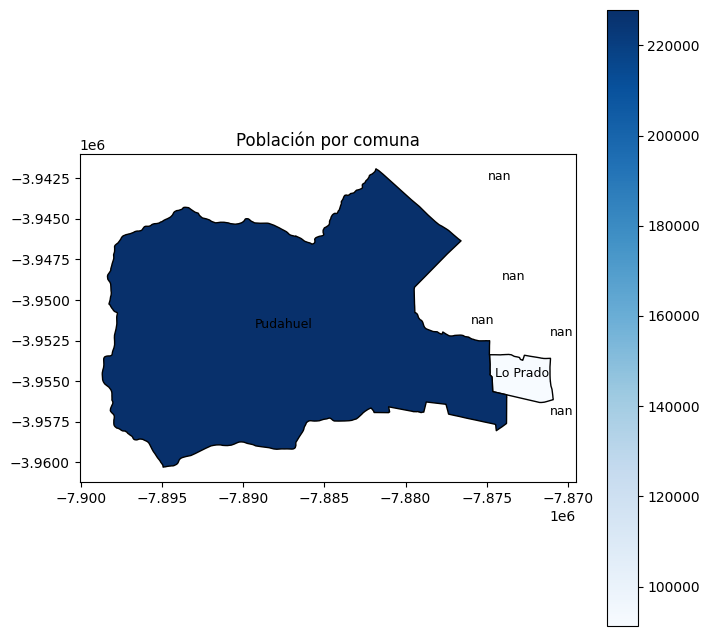

In [ ]:
# 2.1 Population by comuna

# cargar el archivo geográfico
mapa_comunas = gpd.read_file("/content/drive/MyDrive/Ramo_IELE756/comunas.shx")

# calcular población por comuna
pop_comuna = censo_full.groupby("comuna").size().reset_index(name="population")

mapa_pop = mapa_comunas.merge(
    pop_comuna,
    left_on="cod_comuna",
    right_on="comuna",
    how="left"
)

# Distinción de comunas
comuna_names = {
    13117: "Lo Prado",
    13124: "Pudahuel"
}

mapa_pop["comuna_name"] = mapa_pop["comuna"].map(comuna_names)

fig, ax = plt.subplots(figsize=(8,8))

mapa_pop.plot(
    column="population",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax
)

# agregar nombres de comunas
for idx, row in mapa_pop.iterrows():
    ax.annotate(
        row["comuna_name"],
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center",
        fontsize=9,
        color="black"
    )

plt.title("Población por comuna")

plt.show()


In [ ]:
# ver columnas
print(mapa_comunas.columns)

Index(['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna',
       'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna',
       'Provincia', 'geometry'],
      dtype='object')


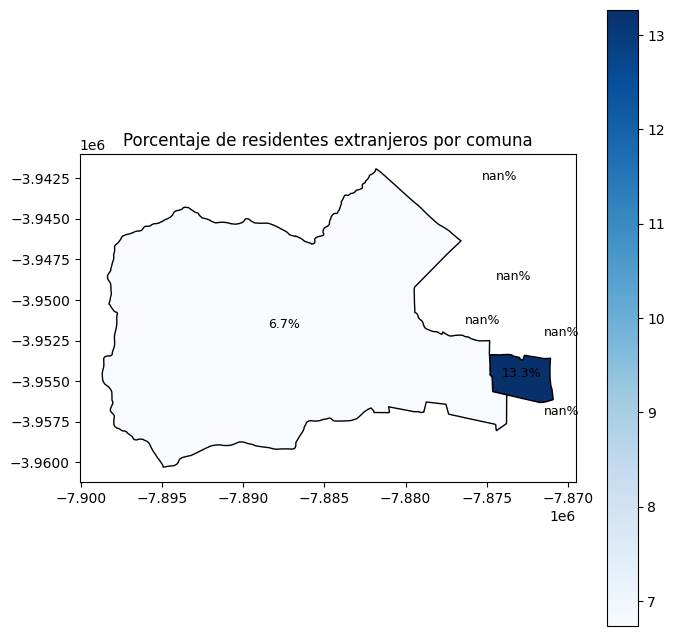

In [ ]:
# 3.2 Choropleth map : % foreign - born by comuna

# crear variable extranjero
censo_full["extranjeros"] = censo_full["p27_nacionalidad_rec"] == 2

# calcular porcentaje por comuna
foreign_share = censo_full.groupby("comuna")["extranjeros"].mean().reset_index()

# convertir a porcentaje
foreign_share["porcentaje"] = foreign_share["extranjeros"] * 100

# unir datos del censo con mapa
mapa_datos = mapa_comunas.merge(
    foreign_share,
    left_on="cod_comuna",
    right_on="comuna",
    how="left"
)

fig, ax = plt.subplots(figsize=(8,8))

mapa_datos.plot(
    column="porcentaje",
    cmap="Blues",
    legend=True,
    edgecolor="black",
    ax=ax
)

# agregar porcentajes
for idx, row in mapa_datos.iterrows():
    ax.annotate(
        f"{row['porcentaje']:.1f}%",
        xy=(row.geometry.centroid.x, row.geometry.centroid.y),
        ha="center",
        fontsize=9,
        color="black"
    )

plt.title("Porcentaje de residentes extranjeros por comuna")

plt.show()

El mapa muestra el porcentaje de residentes extranjeros en las comunas. Pudahuel presenta una menor proporción de extranjeros. Sin embargo, Lo Prado destaca con un porcentaje notablemente superior, que alcanza aproximadamente el 13%. Esto indica que la población extranjera está más concentrada en esa zona específica en comparación con la otra comuna analizada.

In [ ]:
print(pop_comuna)

   comuna  population
0   13117       91290
1   13124      227820


Sin embargo, como se observa en la tabla, aunque en Lo Prado existe una mayor proporción de inmigrantes, la población es menor, por lo que existen menos personas migrantes.

Existe una diferencia de 136.530 personas más en la comuna de Pudahuel que en Lo Prado.

# Part 4

In [ ]:
# Part 4 : Comuna-level summary table

def build_summary(g):

    # separar chilenos y extranjeros
    ch = g[g["p27_nacionalidad_rec"] == 1]
    fr = g[g["p27_nacionalidad_rec"] == 2]

    # población
    pop_total = len(g)
    pop_chilean = len(ch)
    pop_foreign = len(fr)

    pct_foreign = (pop_foreign / pop_total) * 100 if pop_total > 0 else 0

    # edades válidas
    ch_age = ch[ch["edad"] != -99]["edad"]
    fr_age = fr[fr["edad"] != -99]["edad"]

    median_age_chilean = ch_age.median()
    median_age_foreign = fr_age.median()

    # escolaridad (solo 25+)
    ch_school = ch[(ch["edad"] >= 25) & (ch["escolaridad"] != -99)]["escolaridad"]
    fr_school = fr[(fr["edad"] >= 25) & (fr["escolaridad"] != -99)]["escolaridad"]

    mean_schooling_chilean = ch_school.mean()
    mean_schooling_foreign = fr_school.mean()

    # empleo (15-64)
    ch_emp = ch[(ch["edad"] >= 15) & (ch["edad"] <= 64)]
    fr_emp = fr[(fr["edad"] >= 15) & (fr["edad"] <= 64)]

    emp_rate_chilean = (ch_emp["sit_fuerza_trabajo"] == 1).mean()
    emp_rate_foreign = (fr_emp["sit_fuerza_trabajo"] == 1).mean()

    # dependency ratio
    young = g[(g["edad"] >= 0) & (g["edad"] <= 14)]
    old = g[g["edad"] >= 65]
    working = g[(g["edad"] >= 15) & (g["edad"] <= 64)]

    dependency_ratio = (len(young) + len(old)) / len(working) if len(working) > 0 else None

    return pd.Series({
        "pop_total": pop_total,
        "pop_chilean": pop_chilean,
        "pop_foreign": pop_foreign,
        "pct_foreign": pct_foreign,
        "median_age_chilean": median_age_chilean,
        "median_age_foreign": median_age_foreign,
        "mean_schooling_chilean": mean_schooling_chilean,
        "mean_schooling_foreign": mean_schooling_foreign,
        "emp_rate_chilean": emp_rate_chilean,
        "emp_rate_foreign": emp_rate_foreign,
        "dependency_ratio": dependency_ratio
    })

# Crear tabla
summary = censo_full.groupby("comuna").apply(build_summary).reset_index()

# Mapear códigos de comuna a nombres
comuna_names = {
    13117: "Lo Prado",
    13124: "Pudahuel"
}
summary['Comuna Nombre'] = summary['comuna'].map(comuna_names)

# Reordenar columnas para mejor visualización
summary = summary[[
    'Comuna Nombre', 'comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign',
    'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean',
    'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio'
]]

# Aplicar formato para una mejor presentación
styled_summary = summary.style.format({
    'pop_total': '{:,.0f}',
    'pop_chilean': '{:,.0f}', # Población nacida en Chile
    'pop_foreign': '{:,.0f}', # Población nacida en el extranjero
    'pct_foreign': '{:.2f}%', # % personas nacidas en el extranjeros
    'median_age_chilean': '{:,.1f}', # edad media chilenos
    'median_age_foreign': '{:,.1f}', # edad media extranjeros
    'mean_schooling_chilean': '{:,.2f}', # media de escolaridad en chilenos
    'mean_schooling_foreign': '{:,.2f}', # media escolaridad en extranjeros
    'emp_rate_chilean': '{:.2%}', # tasa empleo chilenos
    'emp_rate_foreign': '{:.2%}', # tasa empleo extranjeros
    'dependency_ratio': '{:,.2f}' # índice de dependencia
}).set_caption("Resumen Comparativo de Comunas")

display(styled_summary)

/tmp/ipykernel_2419/3514144262.py:59: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = censo_full.groupby("comuna").apply(build_summary).reset_index()


,Comuna Nombre,comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio
0,Lo Prado,13117,"91,290","78,678","12,110",13.27%,41.0,34.0,11.06,12.00,62.59%,75.42%,0.48
1,Pudahuel,13124,"227,820","210,831","15,344",6.74%,37.0,33.0,11.69,12.44,61.94%,73.86%,0.43


Teniendo una visión comparativa entre las comunas 13117 (Lo Prado) y 13124 (Pudahuel) se tiene que:

**- Población total y área:** Pudahuel cuenta con una población y área significativamente más grande que Lo Prado.

**- Porcentaje de extranjeros:** Lo Prado tiene un porcentaje superior (13.27%) que Pudahuel (6.74%). Asimismo, Lo Prado al poseer una menor área y mayor proporción de inmigrantes, indica una concentración significativamente mayor de migrantes. Así, la proporción de inmigrantes por cada unidad de área también se vería significativamente mayor.

**- Edad mediana:** En ambas comunas, la población chilena es mayor que la población extranjera. Chilenos son en promedio 7 años mayor en Lo Prado y en Pudahuel chilenos son solamente 4 años mayor en promedio.

**- Escolaridad media:** La población extranjera en ambas comunas presenta, en promedio, más años de escolaridad que la población chilena (Pudahuel y Lo Prado).

**- Tasa de empleo:** La tasa de empleo es consistentemente más alta para la población extranjera en ambas comunas, comparado con la población chilena.

**- Tasa de dependecia:** La tasa de dependecia es similar en ambas comunas, indicando una proporcion parecida de población dependiente (jóvenes y ancianos) con respecto a la población en edad de trabajar.